# Confusion matrix — pdfplumber vs LightOnOCR, gemma4:e4b

Path B only (the final, rules-applied output), one matrix per extractor, same model.


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import numpy as np
import matplotlib.pyplot as plt

from dmpbridge.core import paths as P
from dmpbridge.evaluation.evaluate import (
    LABELS, _confusion_from_match, _match_structured, extract_gold,
)
from dmpbridge.evaluation.annotation_rules import resolve_new_gt_path

MODEL = 'gemma4:e4b'
SAMPLES = range(1, 11)
PANELS = {
    'Pdfplumber+Gemma':  P.make_tag(MODEL, 'pdfplumber'),
    'LighOnOCR+Gemma':   'gemma4-e4b_lightonocr_whole_doc',
}

INK, SURFACE, PINK = '#0b0b0b', '#fcfcfb', '#c2185b'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'font.size': 10,
})

CONF, available = {}, []
for name, tag in PANELS.items():
    if not all(P.final_path(tag, n).exists() for n in SAMPLES):
        print(f'not available, skipped: {name}')
        continue
    from collections import defaultdict
    pooled = defaultdict(lambda: defaultdict(int))
    for n in SAMPLES:
        gold = extract_gold(resolve_new_gt_path(n), dedup_question_title=False)
        records, no_gold = _match_structured(P.final_path(tag, n), gold,
                                             dedup_question_title=False)
        this = _confusion_from_match(records, no_gold)
        for k, row in this.items():
            for kk, v in row.items():
                pooled[k][kk] += v
    CONF[name] = pooled
    available.append(name)

print('comparing:', ', '.join(available))


comparing: Pdfplumber+Gemma, LighOnOCR+Gemma


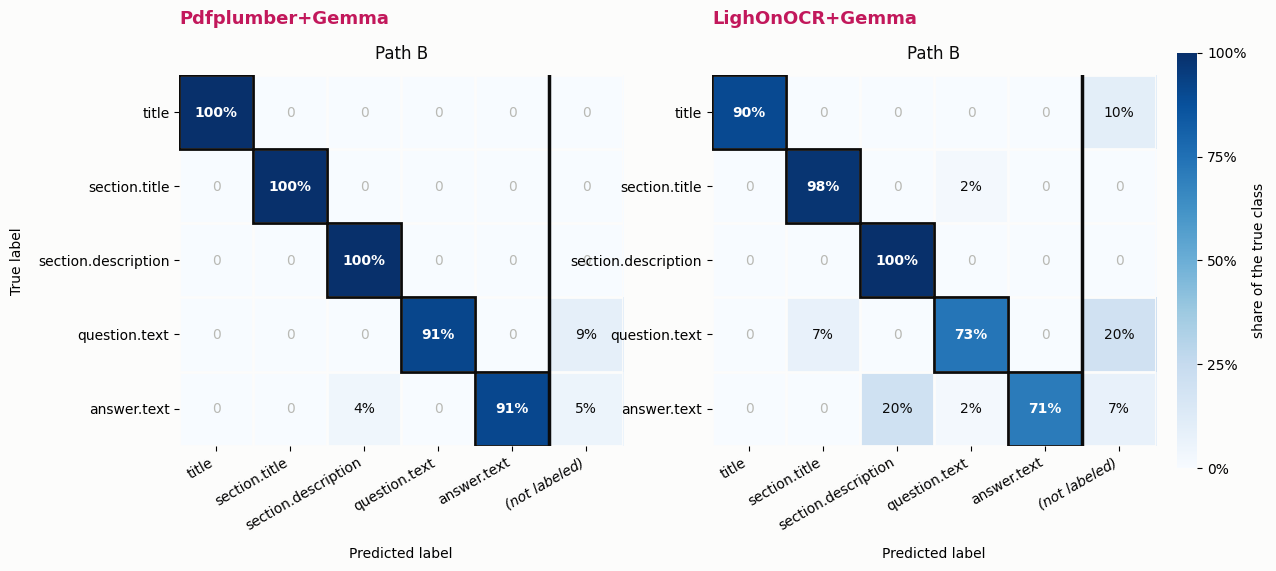

In [2]:
COLS = list(LABELS) + ['(not labeled)']
KEYS = list(LABELS) + ['__missed__']


def build_pct(conf):
    pct = np.zeros((len(LABELS), len(KEYS)))
    for i, t in enumerate(LABELS):
        row_total = sum(conf.get(t, {}).values())
        for j, key in enumerate(KEYS):
            if row_total:
                pct[i, j] = conf.get(t, {}).get(key, 0) / row_total
    return pct


fig, axes = plt.subplots(1, len(available), figsize=(6.6 * len(available), 5.4),
                         squeeze=False)
axes = axes[0]

for ax, name in zip(axes, available):
    cm = build_pct(CONF[name])
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    for i in range(len(LABELS)):
        for j in range(len(KEYS)):
            v = cm[i, j]
            ax.text(j, i, f'{v:.0%}' if v else '0', ha='center', va='center',
                    fontsize=10, fontweight='bold' if i == j else 'normal',
                    color='#b9b9b4' if v == 0 else ('white' if v > 0.55 else INK))
    ax.set_xticks(range(len(COLS)))
    ax.set_xticklabels(COLS, rotation=30, ha='right')
    ax.set_yticks(range(len(LABELS)))
    ax.set_yticklabels(LABELS)
    ax.set_xlabel('Predicted label', labelpad=10)
    ax.set_title('Path B', pad=12)
    ax.set_xticks(np.arange(-.5, len(COLS), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(LABELS), 1), minor=True)
    ax.grid(which='minor', color=SURFACE, linewidth=2)
    ax.tick_params(which='minor', length=0)
    for k in range(len(LABELS)):
        ax.add_patch(plt.Rectangle((k - .5, k - .5), 1, 1, fill=False,
                                   edgecolor=INK, linewidth=2.0, zorder=5))
    ax.axvline(len(LABELS) - 0.5, color=INK, linewidth=2.5, zorder=6)
    ax.get_xticklabels()[-1].set_style('italic')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.text(0.0, 1.14, name, transform=ax.transAxes, fontsize=13, fontweight='bold',
            color=PINK)

axes[0].set_ylabel('True label', labelpad=10)
cbar = fig.colorbar(im, ax=list(axes), fraction=0.025, pad=0.02,
                    label='share of the true class')
cbar.outline.set_visible(False)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0%', '25%', '50%', '75%', '100%'])
plt.show()
